# PPThinning\n\nSimulating point processes by thinning.\n\nPython port of the MATLAB `PPThinning` helpfile (`helpfiles/PPThinning.m`).

## Simulate PP via thinning

Given a conditional intensity function, we generate a point process consistent with this CIF.

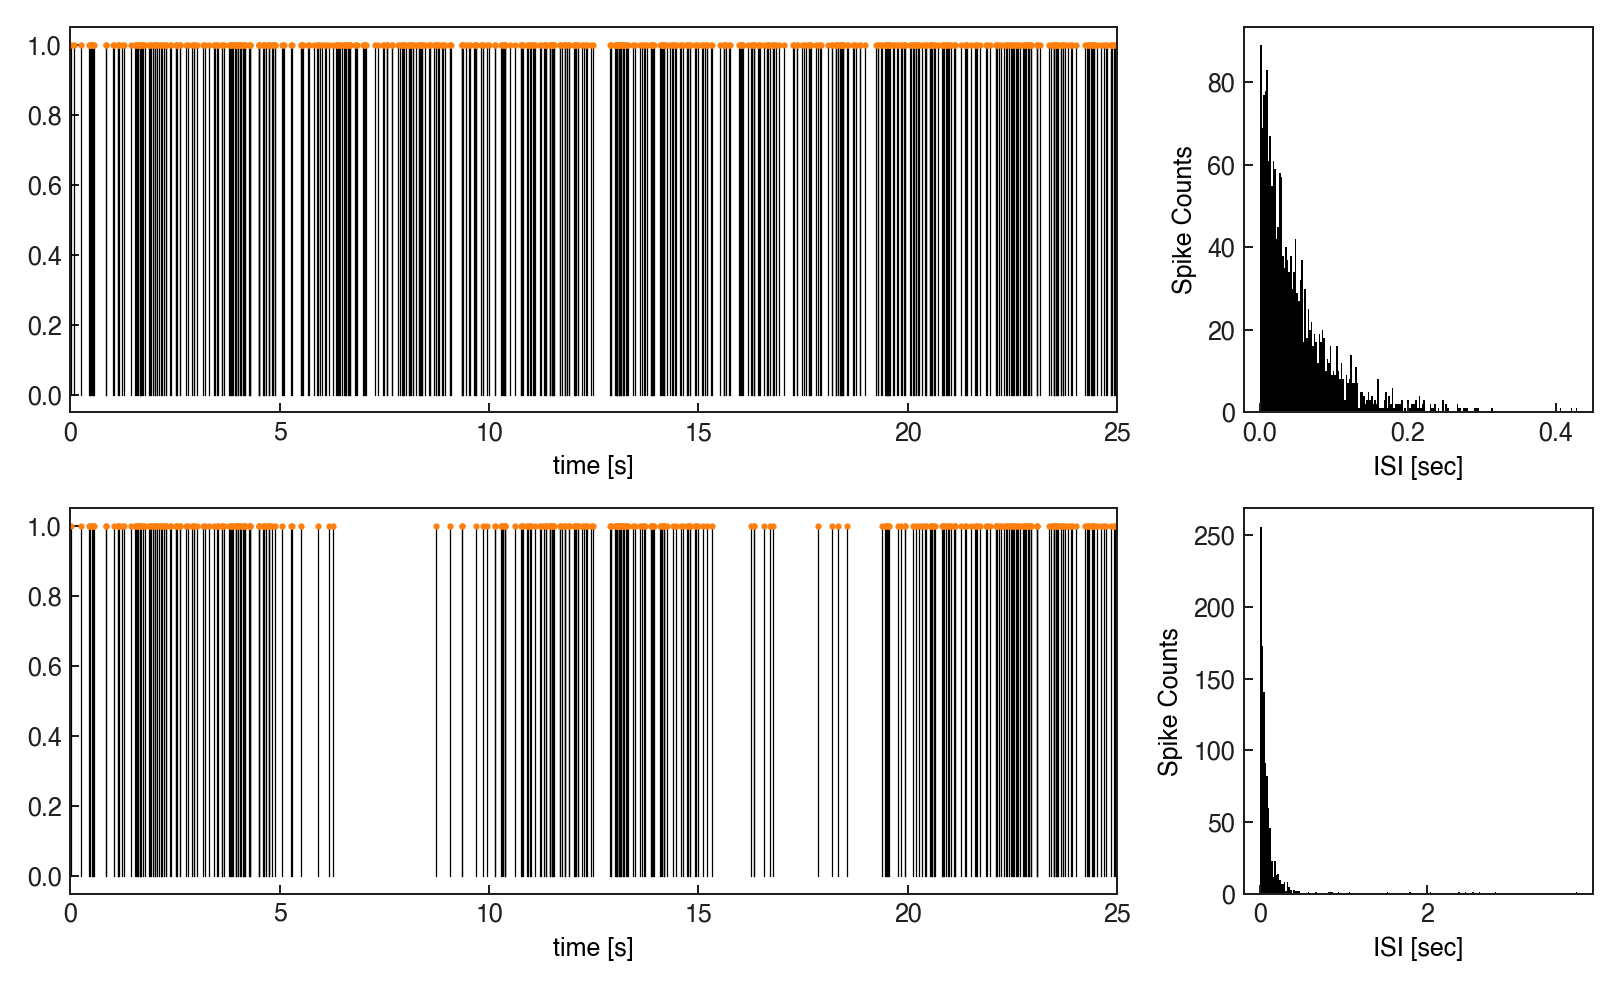

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import Covariate, nspikeTrain, nstColl, CIF
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="PPThinning", output_root=OUTPUT_ROOT, expected_count=4)
def capture(label, fn):
    fig = __tracker.new_figure(label); plt.close(fig); fn(); __tracker._active_fig = plt.gcf()


## Basic Example

In [ ]:
# SECTION 1: Basic Example
delta = 0.001; Tmax = 100; time = np.arange(0, Tmax + delta, delta); f = 0.1
lambdaData = 10*np.sin(2*np.pi*f*time) + 10
lam = Covariate(time, lambdaData, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
lambdaBound = float(np.max(lambdaData))
rng = np.random.default_rng(0)
N = int(lambdaBound * 1.5 * Tmax)
u = rng.random(N); w = -np.log(u) / lambdaBound
tSpikes = np.cumsum(w); tSpikes = tSpikes[tSpikes <= Tmax]
ratio = np.asarray(lam.getValueAt(tSpikes)).flatten() / lambdaBound
u2 = rng.random(len(ratio)); tThin = tSpikes[ratio >= u2]
n1 = nspikeTrain(tSpikes); n2 = nspikeTrain(tThin)

## Compare Constant rate process vs. thinned process

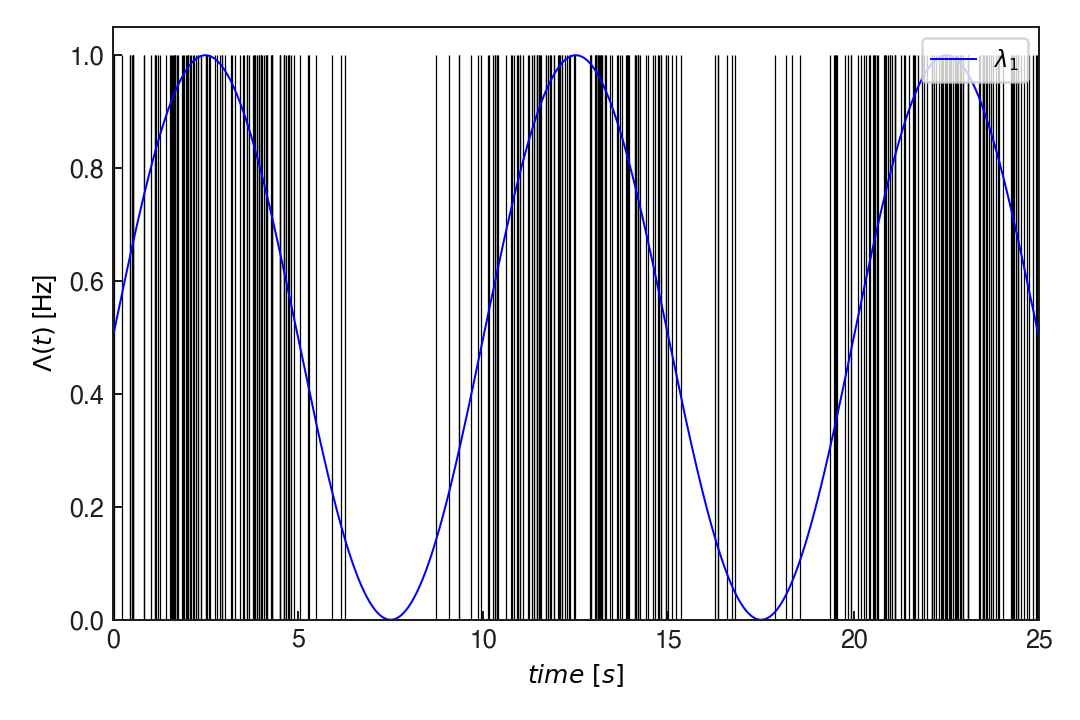

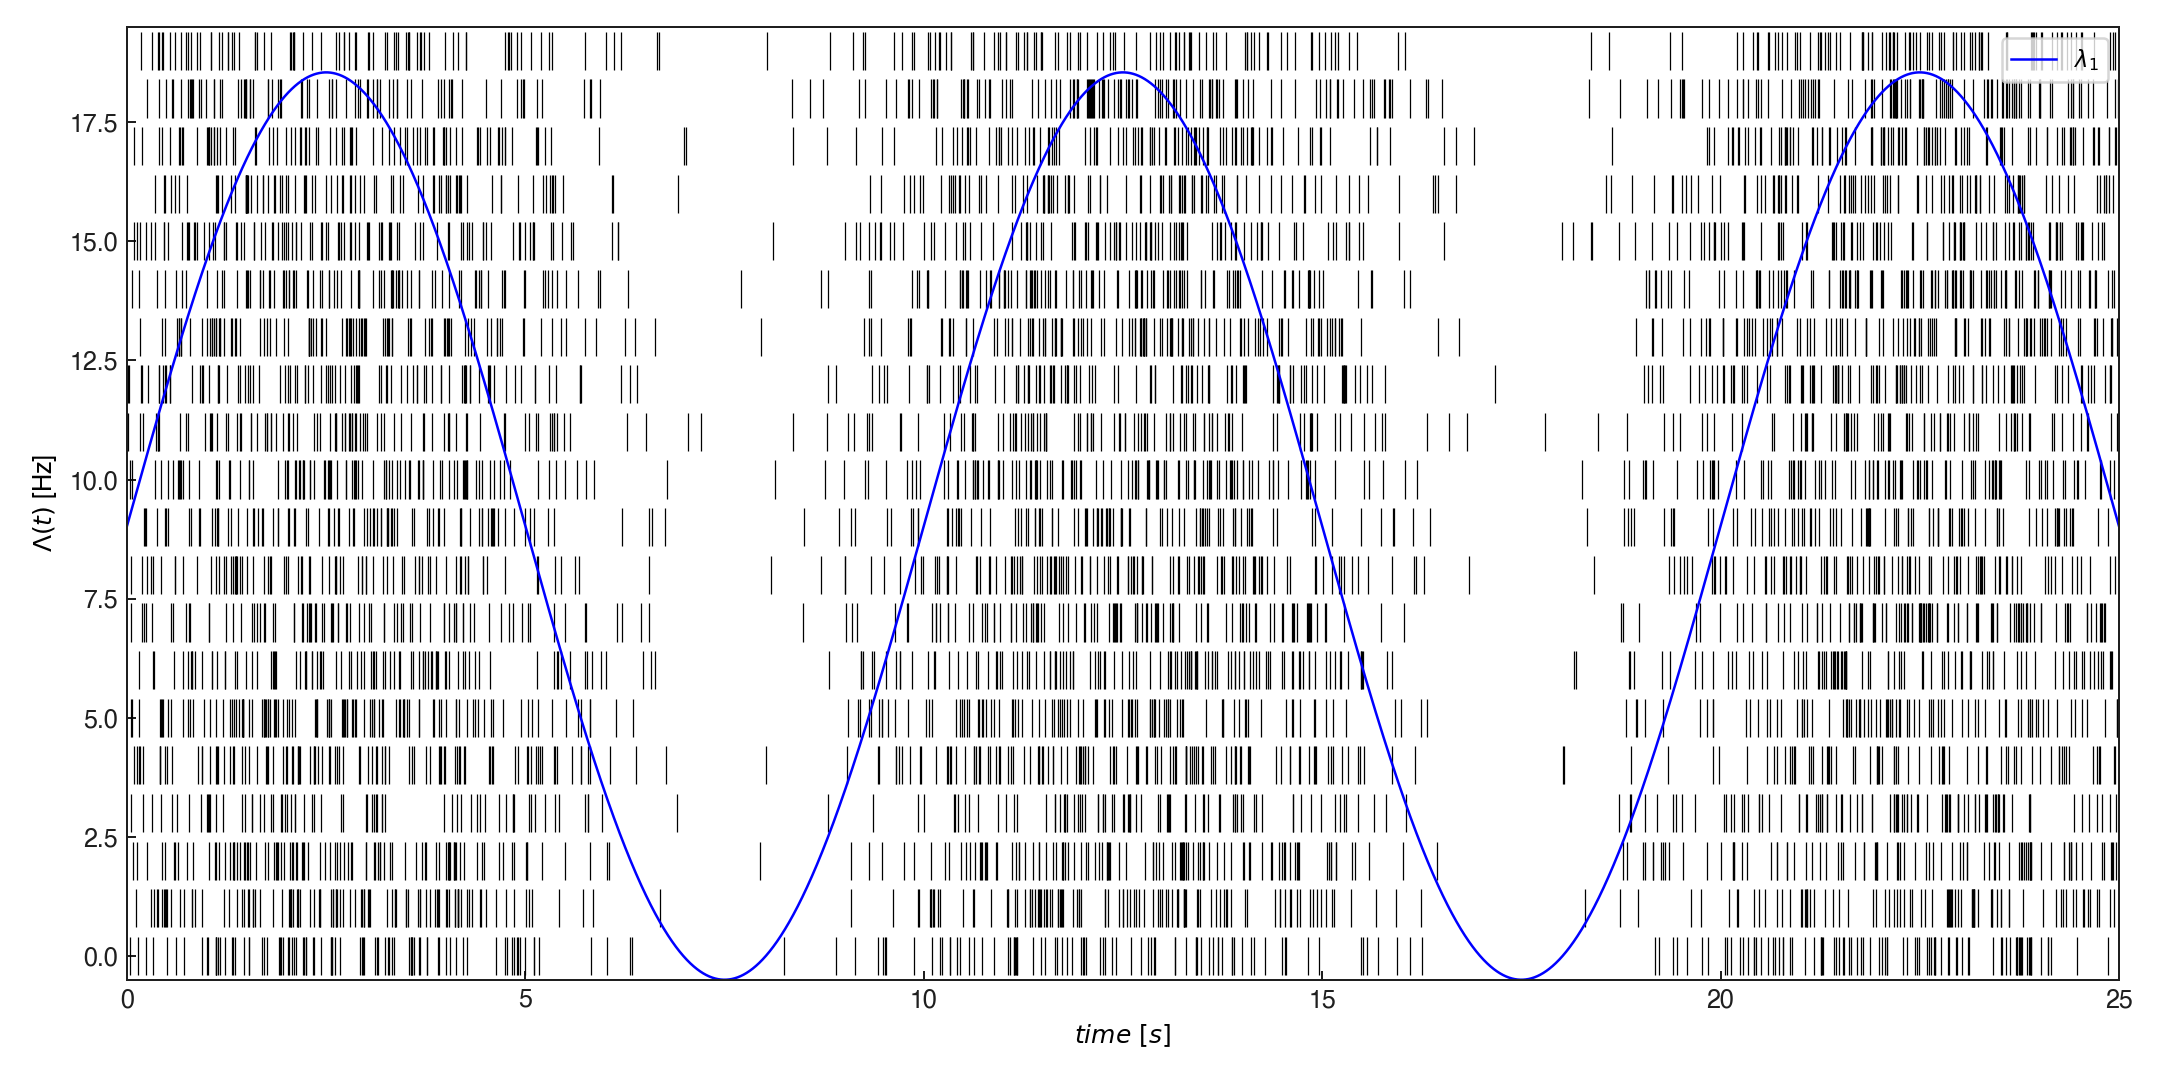

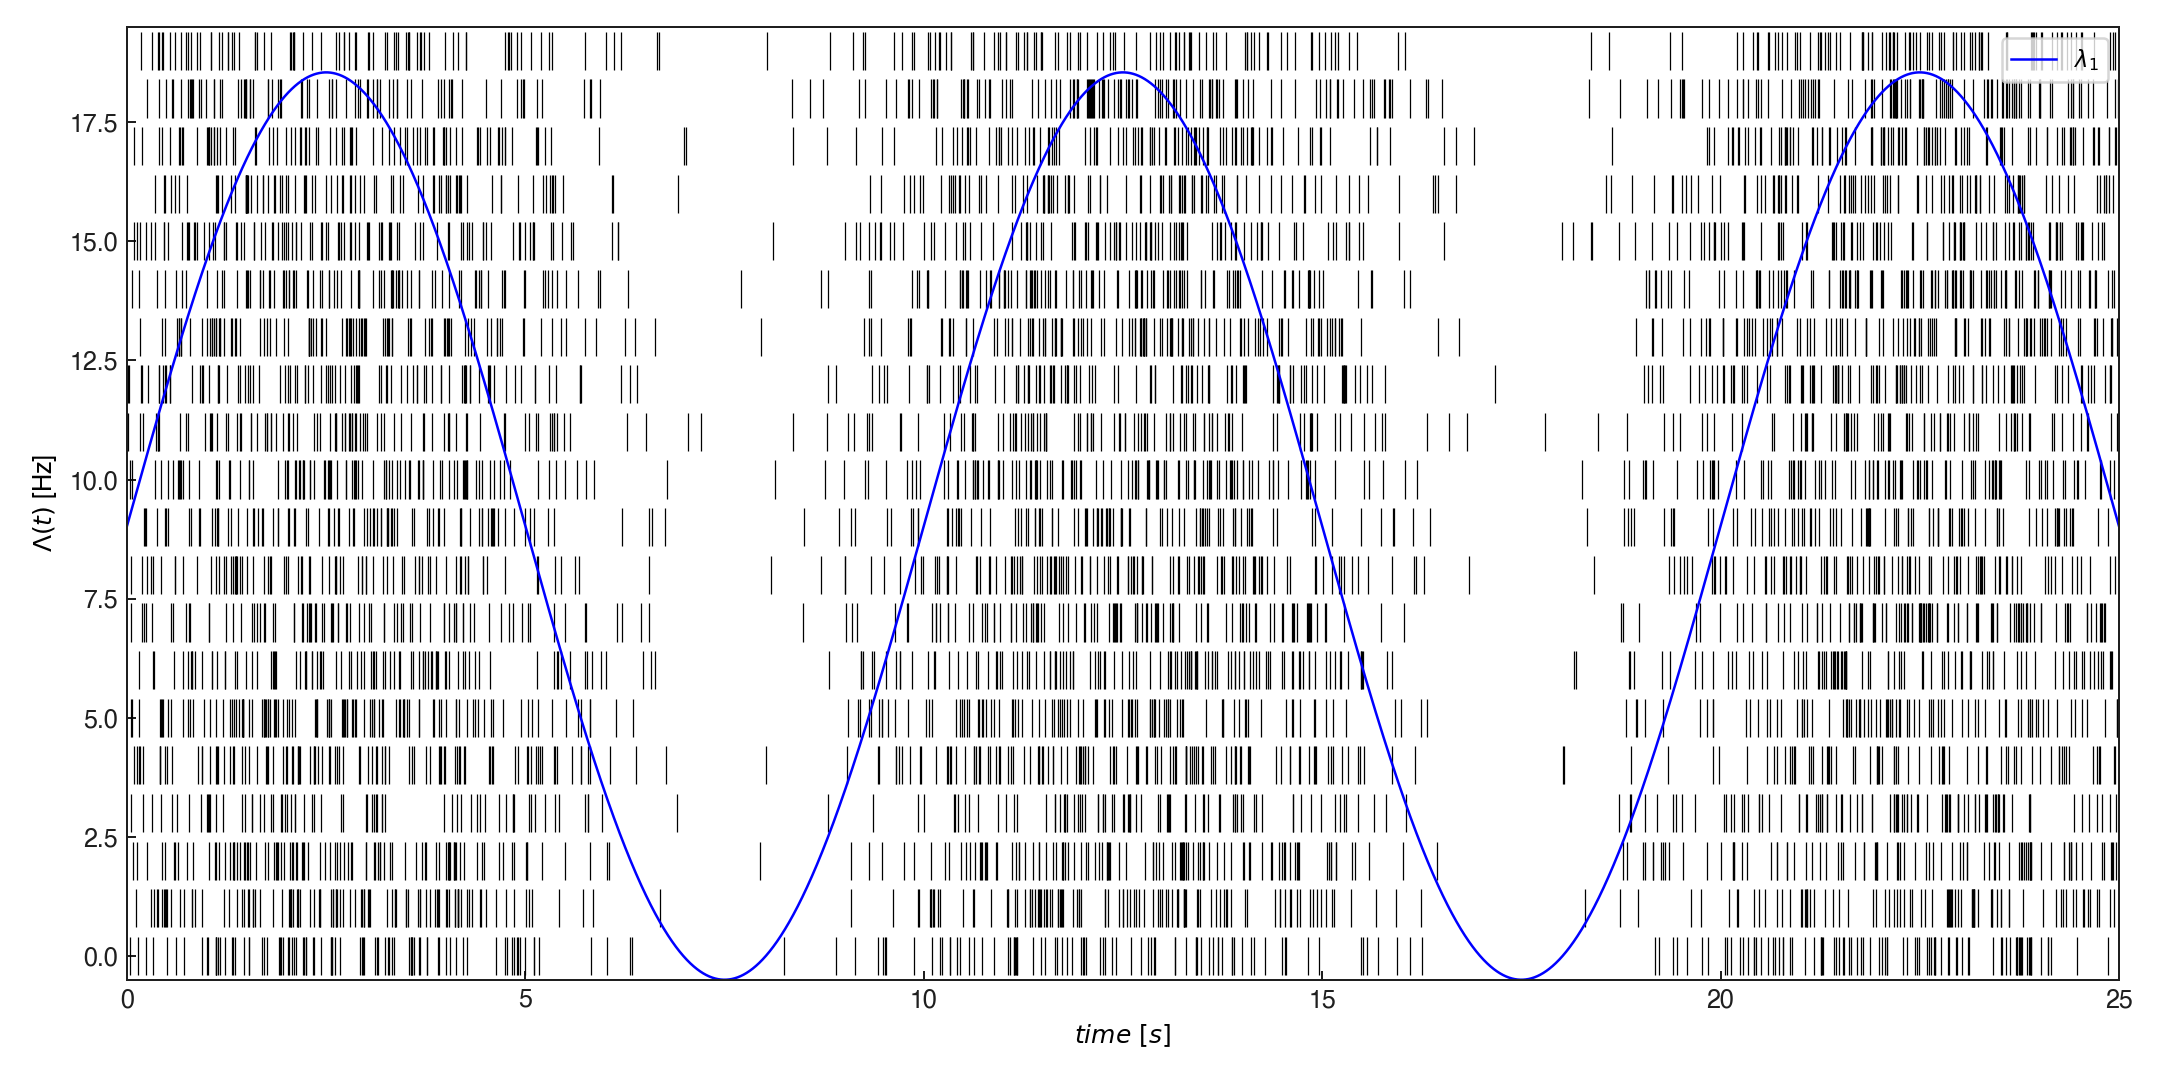

In [ ]:
# SECTION 2: Compare Constant rate process vs. thinned process
def _start_fig(label, figsize=(8.0, 4.5)):
    # Open a tracker slot, then discard the placeholder axes/title cleanly so
    # nothing from the placeholder leaks into the saved PNG.
    fig = __tracker.new_figure(label)
    fig.clf()
    fig.set_size_inches(*figsize)
    __tracker._active_fig = fig
    __tracker._active_ax = None
    return fig

# Figure 1: 2 rows x 2 cols with width_ratios=[3,1] — raster wide, ISI hist narrow.
# Matches MATLAB layout where each row pairs a tall wide raster with a tight
# ISI histogram on the right. MATLAB uses no panel titles, labels ISI in
# seconds, and renders hist() as many fine bins filled solid black — mirror
# that here with bins=200 and a solid-black stepfilled style.
fig1 = _start_fig("constant-rate vs thinned process", figsize=(9.0, 5.5))
gs = fig1.add_gridspec(2, 2, width_ratios=[3, 1])
ax = fig1.add_subplot(gs[0, 0]); n1.plot(currentHandle=ax)
ax.plot(tSpikes, np.ones_like(tSpikes), '.', color='tab:orange', markersize=3)
ax.set_xlim(0, Tmax/4); ax.set_xlabel('time [s]')
ax = fig1.add_subplot(gs[0, 1])
ax.hist(np.diff(tSpikes), bins=200, color='black', edgecolor='black', linewidth=0.0)
ax.set_xlabel('ISI [sec]'); ax.set_ylabel('Spike Counts')
ax = fig1.add_subplot(gs[1, 0]); n2.plot(currentHandle=ax)
ax.plot(tThin, np.ones_like(tThin), '.', color='tab:orange', markersize=3)
ax.set_xlim(0, Tmax/4); ax.set_xlabel('time [s]')
# Bottom-right: thinned-process ISI histogram (matches MATLAB hist(diff(tThin))).
ax = fig1.add_subplot(gs[1, 1])
ax.hist(np.diff(tThin), bins=200, color='black', edgecolor='black', linewidth=0.0)
ax.set_xlabel('ISI [sec]'); ax.set_ylabel('Spike Counts')
fig1.tight_layout()

# Figure 2: thinned spikes + scaled rate p(t) — single panel matching MATLAB's
# squarish portrait aspect. MATLAB labels the y-axis italic "Lambda(t) [Hz]"
# and the x-axis italic "time [s]", with integer ticks every 5 s.
fig2 = _start_fig("thinned spikes + scaled rate", figsize=(6.0, 4.0))
ax2 = fig2.add_subplot(1,1,1)
ax2.vlines(tThin, 0, 1, color='k', linewidth=0.5)
# MATLAB plot() default LineWidth is ~0.5; use 0.8 so the rate overlay sits
# behind raster ticks rather than dominating the panel.
ax2.plot(time, lambdaData / lambdaBound, "b", linewidth=0.8, label=r'$\lambda_1$')
ax2.set_xlim(0, Tmax/4); ax2.set_ylim(0, 1.05)
ax2.set_xlabel(r'$time\ [s]$'); ax2.set_ylabel(r'$\Lambda(t)$ [Hz]')
# Match MATLAB's integer-second x-ticks (0, 5, 10, 15, 20, 25).
from matplotlib.ticker import MultipleLocator as _MultipleLocator, FormatStrFormatter as _FormatStrFormatter
ax2.xaxis.set_major_locator(_MultipleLocator(5))
ax2.xaxis.set_major_formatter(_FormatStrFormatter('%d'))
ax2.legend(loc='upper right')
fig2.tight_layout()

## Simulate multiple realizations of a point process via thinning

The CIF class can generated realizations of a point process given a conditional intensity function (defined as a Covariate or SignalObj)

In [ ]:
# SECTION 3: Simulate multiple realizations of a point process via thinning
spikeColl = CIF.simulateCIFByThinningFromLambda(lam, 20, seed=1)

# Figure 3: stacked-raster ensemble (one row per realization) over the full
# simulation window 0..Tmax/4. MATLAB renders each realization as its own
# row of tick marks so the lambda(t) curve modulates row-density rather than
# being overlaid on a single dense block. Use matplotlib eventplot for the
# rows, and overlay the blue lambda(t) curve on a twin-axis so the sinusoid
# keeps its Hz scale while the raster reads as a row stack.
fig3 = _start_fig("20 thinning realizations + rate", figsize=(12.0, 6.0))
ax3 = fig3.add_subplot(1,1,1)
_lam_max = float(np.max(lambdaData))
_events = [np.asarray(spikeColl.getNST(i).spikeTimes)
           for i in range(spikeColl.numSpikeTrains)]
ax3.eventplot(_events, colors='k', linewidths=0.5, linelengths=0.8)
ax3.set_xlim(0, Tmax/4)
ax3.set_ylim(-0.5, spikeColl.numSpikeTrains - 0.5)
ax3.set_xlabel(r'$time\ [s]$')
ax3.set_ylabel(r'$\Lambda(t)$ [Hz]')
# Overlay lambda(t) on a twin y-axis so the sinusoid retains its Hz scale.
_ax3b = ax3.twinx()
_ax3b.plot(time, lambdaData, "b", linewidth=1.0, label=r'$\lambda_1$')
_ax3b.set_ylim(0, _lam_max * 1.05)
_ax3b.set_yticks([])
_ax3b.legend(loc='upper right')

# Figure 4: same stacked-raster ensemble over the full 25 s window so the
# sinusoidal lambda(t) modulation across all peaks/troughs is visible. Same
# landscape aspect ratio as MATLAB.
fig4 = _start_fig("20 realizations + rate (full window)", figsize=(12.0, 6.0))
ax4 = fig4.add_subplot(1,1,1)
ax4.eventplot(_events, colors='k', linewidths=0.5, linelengths=0.8)
ax4.set_xlim(0, Tmax/4)
ax4.set_ylim(-0.5, spikeColl.numSpikeTrains - 0.5)
ax4.set_xlabel(r'$time\ [s]$')
ax4.set_ylabel(r'$\Lambda(t)$ [Hz]')
_ax4b = ax4.twinx()
_ax4b.plot(time, lambdaData, "b", linewidth=1.0, label=r'$\lambda_1$')
_ax4b.set_ylim(0, _lam_max * 1.05)
_ax4b.set_yticks([])
_ax4b.legend(loc='upper right')

__tracker.finalize()